# Part 2 — Simulation of Airport Check-In and Security Lines

This notebook solves **ONLY Part 2** of the project using the **discrete-event simulation (DES)** and **Monte Carlo replication** methodology emphasized in class.

The notebook is organized to mirror the lecture workflow:

1. **Define the system state**
2. **Identify the event types**
3. **Determine the statistics to track**
4. **Write event handlers and maintain a future event list**
5. **Run replications and report averages with confidence intervals**
6. **Study steady-state behavior with warm-up periods when needed**

The project asks us to study a tandem airport pre-boarding system with three stages:

- **check-in line**
- **commute period**
- **security line**

We will build a DES model for this system, then use Monte Carlo replications to reduce randomness and quantify uncertainty with confidence intervals.

## Project data used in this notebook

From the project statement:

- Interarrival times to check-in are **Exponential** with rate **$(\lambda$)** customers per minute
- Check-in service times $(s_1)$ are **Lognormal**, with  
  $
  \, \log(s_1) \sim \mathcal{N}(\mu_1, \sigma_1^2), \quad \mu_1 = 0.1, \; \sigma_1 = 0.1
  $
- Default number of check-in servers: **$(n_1 = 25)$**
- Commute time $(s_2)$ is the **positive part of a Normal(6, 1²)** random variable (so we keep drawing Normal samples until the value is positive)
- Security service times $(s_3)$ are **Exponential** with rate **2 per minute**
- Default number of security screening stations: **$(n_3 = 10)$**

The performance measures are:

- **$L$** = average number of people in the pre-boarding system (time average)
- **$W$** = average time spent in the pre-boarding system (customer average)
- **$S$** = average number of customers completing pre-boarding per minute

We also study the cost function for the security staffing problem:

- $ \text{cost} = h \cdot L - R \cdot S + c \cdot n_3$;    

where **$(h=1)$** is the per person cost that penalizes the total number of people in the system, **$(R=1)$** is the reward per minute per person for completing service, and **$(c=10)$** denotes the cost per minute of hiring one attendant.

## Simulation methodology from the lecture slides

The lecture slides on DES emphasize that a simulation model should explicitly track:

- a **simulation clock**
- a **system state**
- a **future event list (FEL)**
- **statistical counters**

That is exactly what we do below.

For this tandem multi-server queue, the natural event types are:

1. **External arrival** to the check-in line
2. **Check-in service completion**
3. **Commute completion** (arrival to security)
4. **Security service completion**

At each event time we:

- advance the clock
- update time-average statistics
- update the state
- schedule any new future events triggered by the current event

This is the same event-driven logic presented in the lecture notes for single-server queues, generalized here to a tandem multi-server system.

In [3]:
import math
import heapq
from dataclasses import dataclass, field
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as st

In [4]:
# ------------------------------
# Random variate generators
# ------------------------------
# These helper functions sample from the distributions given in the project.
# They are kept separate from the main DES logic to make the code easier to read.

def sample_interarrival(rng, arrival_rate):
    """Sample the time until the next external arrival."""
    return rng.exponential(1.0 / arrival_rate)

def sample_checkin_service(rng, mu=0.1, sigma=0.1):
    """Sample a lognormal service time for check-in."""
    return rng.lognormal(mean=mu, sigma=sigma)

def sample_positive_normal(rng, mean=6.0, sd=1.0):
    """Sample from the positive part of a normal distribution.

    The project explicitly says to keep drawing from the normal distribution
    until we obtain a positive value.
    """
    x = -1.0
    while x <= 0:
        x = rng.normal(mean, sd)
    return x

def sample_security_service(rng, rate=2.0):
    """Sample an exponential service time for security screening."""
    return rng.exponential(1.0 / rate)

## DES state and event representation

We will represent each future event as a small record containing:

- the event time
- a priority number (used to break ties consistently)
- the event type
- the customer id involved in that event

The tie-breaking priority is not the main modeling idea here, but it is helpful in programming DES models because two events can occur at the exact same time.

In [5]:
@dataclass(order=True)
class Event:
    # The dataclass is ordered so that heapq can sort events by time first.
    time: float
    priority: int
    etype: str = field(compare=False)
    cid: int = field(compare=False)

## Core DES model

Before reading the code, here is the modeling logic in words.

### System state

At any point in time the state contains:

- customers waiting for check-in
- number of busy check-in servers
- number of customers currently commuting
- customers waiting for security
- number of busy security servers

This contains all information needed to determine the future evolution of the system and compute the statistics of interest, which is exactly what the lecture slides call the **state variable**.

### Statistical counters

We track:

- the area under **number in system vs time** to compute $(L)$
- departure counts to compute $(S)$
- total sojourn time of completed customers to compute $(W)$

### Event handlers

- **Arrival event**  
  Adds a customer to check-in immediately if a server is free; otherwise the customer joins the check-in queue.  
  Also schedules the next external arrival.

- **Check-in departure event**  
  Sends the completed customer into the commute stage and schedules the commute completion.  
  If someone is waiting in the check-in queue, service starts immediately for the next customer.

- **Commute completion event**  
  Sends the customer to security immediately if a screening station is free; otherwise the customer joins the security queue.

- **Security departure event**  
  The customer leaves the pre-boarding system.  
  If someone is waiting in the security queue, the next service begins immediately.

### Two ways we will use this simulator

1. **Terminating simulation over one day**  
   This matches the project's Monte Carlo replication request.

2. **Steady-state style analysis with a warm-up period**  
   This matches the lecture discussion of the initial transient problem and is useful for the stability / Little's Law / optimization experiments.

In [6]:
DAY_MINUTES = 24 * 60

def simulate_preboarding(
    arrival_rate=10.0,
    n1=25,
    n3=10,
    day_length=DAY_MINUTES,
    warmup=0.0,
    collect_time=None,
    seed=1234,
):
    """Run one replication of the tandem pre-boarding DES.

    Parameters
    ----------
    arrival_rate : float
        External arrival rate lambda in customers per minute.
    n1 : int
        Number of check-in servers.
    n3 : int
        Number of security servers.
    day_length : float
        Used for terminating 'one day' simulations when collect_time is None.
    warmup : float
        Length of the warm-up period. Statistics are not collected before this time.
    collect_time : float or None
        If None, collect statistics over [0, day_length].
        If not None, collect over [warmup, warmup + collect_time].
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    dict with keys L, W, S and some auxiliary counts.

    Notes
    -----
    This function is intentionally written in a very explicit style with lots of
    comments, because the goal of the notebook is not only to produce answers,
    but also to show clearly how the DES logic works.
    """

    rng = np.random.default_rng(seed)

    # ------------------------------------------------------------
    # Define the time window over which we actually collect stats.
    # ------------------------------------------------------------
    # Case 1: terminating simulation over a single day
    if collect_time is None:
        collect_start = 0.0
        collect_end = day_length
        run_end = day_length
    # Case 2: steady-state style simulation
    else:
        collect_start = warmup
        collect_end = warmup + collect_time
        run_end = collect_end

    # ------------------------------------------------------------
    # Future Event List (FEL)
    # ------------------------------------------------------------
    # We use a min-heap so that the next imminent event can always
    # be popped efficiently.
    fel = []

    # ------------------------------------------------------------
    # System state
    # ------------------------------------------------------------
    # q1 = queue waiting for check-in
    # q3 = queue waiting for security
    # busy1 = number of currently busy check-in servers
    # busy3 = number of currently busy security servers
    # in_commute = number of customers currently commuting
    q1 = deque()
    q3 = deque()
    busy1 = 0
    busy3 = 0
    in_commute = 0

    # Keep the airport-entry time of each customer so that when the
    # customer departs after security we can compute total time in system.
    entry_time = {}

    # ------------------------------------------------------------
    # Statistical counters
    # ------------------------------------------------------------
    # To compute L, we integrate the number-in-system over time.
    area_num_in_system = 0.0

    # We need the previous event time for area accumulation.
    last_event_time = 0.0

    # To compute W and S over the collection window:
    departures_in_window = 0
    sojourn_sum_in_window = 0.0

    # Not strictly required, but useful as a diagnostic.
    arrivals_in_window = 0
    total_completed = 0

    # ------------------------------------------------------------
    # Simulation clock and customer id generation
    # ------------------------------------------------------------
    t = 0.0
    next_cid = 0

    # Schedule the very first external arrival.
    first_arrival = sample_interarrival(rng, arrival_rate)
    heapq.heappush(fel, Event(first_arrival, 0, "arrival", next_cid))
    next_cid += 1

    def num_in_system():
        """Current total number of customers in the pre-boarding system."""
        return len(q1) + busy1 + in_commute + len(q3) + busy3

    # ------------------------------------------------------------
    # Main event loop
    # ------------------------------------------------------------
    while fel:
        # Get the next imminent event from the FEL.
        ev = heapq.heappop(fel)

        # If the event occurs after our run horizon, we stop.
        if ev.time > run_end:
            break

        # --------------------------------------------------------
        # Update time-average statistics BEFORE changing the state.
        # --------------------------------------------------------
        # Between last_event_time and ev.time, the system state stays constant,
        # so the integral under N(t) is simply:
        #     current_number_in_system * time_length
        #
        # Because we may be using a warm-up period, we only add the overlap
        # with the collection interval [collect_start, collect_end].
        start = max(last_event_time, collect_start)
        end = min(ev.time, collect_end)
        if end > start:
            area_num_in_system += num_in_system() * (end - start)

        # Advance clock
        last_event_time = ev.time
        t = ev.time

        # ========================================================
        # Event handler: External arrival
        # ========================================================
        if ev.etype == "arrival":
            cid = ev.cid

            # Record this customer's airport-entry time
            entry_time[cid] = t

            if collect_start <= t <= collect_end:
                arrivals_in_window += 1

            # Schedule the NEXT external arrival
            next_arrival_time = t + sample_interarrival(rng, arrival_rate)
            if next_arrival_time <= run_end:
                heapq.heappush(fel, Event(next_arrival_time, 0, "arrival", next_cid))
                next_cid += 1

            # If a check-in server is free, start service immediately.
            # Otherwise, the customer waits in the check-in queue.
            if busy1 < n1:
                busy1 += 1
                service_time = sample_checkin_service(rng)
                heapq.heappush(fel, Event(t + service_time, 1, "checkin_departure", cid))
            else:
                q1.append(cid)

        # ========================================================
        # Event handler: Check-in service completion
        # ========================================================
        elif ev.etype == "checkin_departure":
            cid = ev.cid

            # The customer leaves check-in.
            # If someone is already waiting, the just-freed server immediately
            # starts serving the next person, so busy1 stays the same.
            if q1:
                next_id = q1.popleft()
                service_time = sample_checkin_service(rng)
                heapq.heappush(fel, Event(t + service_time, 1, "checkin_departure", next_id))
            else:
                busy1 -= 1

            # The completed customer enters the commute stage.
            in_commute += 1
            commute_time = sample_positive_normal(rng)
            heapq.heappush(fel, Event(t + commute_time, 2, "commute_completion", cid))

        # ========================================================
        # Event handler: Commute completion (arrival to security)
        # ========================================================
        elif ev.etype == "commute_completion":
            cid = ev.cid

            # Customer is no longer commuting
            in_commute -= 1

            # If a security station is free, start security immediately.
            # Otherwise join the security queue.
            if busy3 < n3:
                busy3 += 1
                service_time = sample_security_service(rng)
                heapq.heappush(fel, Event(t + service_time, 3, "security_departure", cid))
            else:
                q3.append(cid)

        # ========================================================
        # Event handler: Security service completion
        # ========================================================
        elif ev.etype == "security_departure":
            cid = ev.cid
            total_completed += 1

            # Free a security server, or immediately give it to the next
            # waiting customer if the security queue is nonempty.
            if q3:
                next_id = q3.popleft()
                service_time = sample_security_service(rng)
                heapq.heappush(fel, Event(t + service_time, 3, "security_departure", next_id))
            else:
                busy3 -= 1

            # If the departure occurs inside the collection window,
            # update W and S statistics.
            if collect_start <= t <= collect_end:
                departures_in_window += 1
                sojourn_sum_in_window += (t - entry_time[cid])

            # Customer has left the entire system
            entry_time.pop(cid, None)

        else:
            raise ValueError(f"Unknown event type: {ev.etype}")

    # ------------------------------------------------------------
    # One last area update in case the final event happened before
    # the end of the collection interval.
    # ------------------------------------------------------------
    start = max(last_event_time, collect_start)
    end = collect_end
    if end > start:
        area_num_in_system += num_in_system() * (end - start)

    # ------------------------------------------------------------
    # Compute the three requested performance measures
    # ------------------------------------------------------------
    collection_length = collect_end - collect_start
    L = area_num_in_system / collection_length
    W = sojourn_sum_in_window / departures_in_window if departures_in_window > 0 else math.nan
    S = departures_in_window / collection_length

    return {
        "L": L,
        "W": W,
        "S": S,
        "completed": departures_in_window,
        "arrivals_in_window": arrivals_in_window,
        "total_completed": total_completed,
    }

In [7]:
# Quick sanity check: one terminating replication with default project parameters
single_run = simulate_preboarding(arrival_rate=10, n1=25, n3=10, seed=2026)
single_run

{'L': 76.55243397641254,
 'W': 7.5998692872814955,
 'S': 10.040972222222223,
 'completed': 14459,
 'arrivals_in_window': 14547,
 'total_completed': 14459}

The sanity-check output should look sensible:

- $(S)$ should be close to the arrival rate 10 customers/minute for the default stable system
- $(L)$ should be positive and moderate
- $(W)$ should be a few minutes, not hundreds of minutes, under the default staffing

Now we build the Monte Carlo layer on top of the DES model.

In [8]:
# --------------------------------------------
# Monte Carlo reporting helpers
# --------------------------------------------

def mean_ci(values, alpha=0.05):
    """Return sample mean and a two-sided t confidence interval."""
    arr = np.asarray(values, dtype=float)
    n = arr.size
    mean = arr.mean()
    if n == 1:
        return mean, np.nan, np.nan, np.nan
    s = arr.std(ddof=1)
    tcrit = st.t.ppf(1 - alpha/2, df=n-1)
    half_width = tcrit * s / math.sqrt(n)
    return mean, mean - half_width, mean + half_width, half_width

def run_replications(
    arrival_rate=10.0,
    n1=25,
    n3=10,
    day_length=DAY_MINUTES,
    warmup=0.0,
    collect_time=None,
    nrep=30,
    seed0=1000,
):
    """Run multiple replications and return both raw outputs and a summary table."""
    outputs = []
    for r in range(nrep):
        out = simulate_preboarding(
            arrival_rate=arrival_rate,
            n1=n1,
            n3=n3,
            day_length=day_length,
            warmup=warmup,
            collect_time=collect_time,
            seed=seed0 + r,
        )
        out["replication"] = r + 1
        outputs.append(out)

    df = pd.DataFrame(outputs)

    summary_rows = []
    for metric in ["L", "W", "S"]:
        mean, lo, hi, hw = mean_ci(df[metric].values)
        summary_rows.append({
            "metric": metric,
            "mean": mean,
            "ci_lower": lo,
            "ci_upper": hi,
            "half_width": hw,
        })

    summary = pd.DataFrame(summary_rows)
    return df, summary

## Part 2.3 — One-day Monte Carlo simulation with confidence intervals

The project explicitly asks us to simulate the system over the course of **a single day**, repeat for **\(N_{rep}\)** replications, and report the **average performance measures** together with **confidence intervals**.

Below we use the default project parameters:

- $(\lambda = 10)$
- $(n_1 = 25)$
- $(n_3 = 10)$

and run 30 one-day replications.

In [9]:
default_daily_df, default_daily_summary = run_replications(
    arrival_rate=10,
    n1=25,
    n3=10,
    day_length=DAY_MINUTES,
    warmup=0.0,
    collect_time=None,   # terminating one-day simulation
    nrep=30,
    seed0=3000,
)

default_daily_summary

,metric,mean,ci_lower,ci_upper,half_width
0,L,75.866199,75.655066,76.077333,0.211134
1,W,7.615112,7.611036,7.619189,0.004076
2,S,9.935185,9.907454,9.962917,0.027732


### Interpretation of the one-day Monte Carlo output

- The **mean** column is the Monte Carlo estimate of the performance measure
- The confidence interval quantifies the remaining randomness across replications
- A relatively narrow interval means the replication count is doing a good job reducing Monte Carlo noise

This is the same reporting philosophy emphasized in the Monte Carlo lecture: simulation output is random, so we should not report only a single number without uncertainty quantification.

In [10]:
# A compact display of the one-day default system results
default_daily_summary.style.format({
    "mean": "{:.4f}",
    "ci_lower": "{:.4f}",
    "ci_upper": "{:.4f}",
    "half_width": "{:.4f}",
})

,metric,mean,ci_lower,ci_upper,half_width
0,L,75.8662,75.6551,76.0773,0.2111
1,W,7.6151,7.6110,7.6192,0.0041
2,S,9.9352,9.9075,9.9629,0.0277


## Why we now switch to warm-up based steady-state analysis for the task experiments

The project's **Task 1** asks us to:

- find the range of arrival rates for which the system is stable
- study $(L)$ and $(W)$ as the arrival rate changes
- discover Little's Law

Those are fundamentally **long-run / steady-state** questions, not just one-day terminating questions.

The DES lecture notes discuss the **initial transient problem** and recommend using a **warm-up period** before collecting statistics for steady-state style analysis. So for the next sections we use:

- a **warm-up period**
- then a long **collection interval**

This is exactly the simulation methodology recommended in class for studying long-run behavior.

## Part 2.4 Task 1 — Arrival rate vs performance

### Theoretical intuition before simulation

The system is a tandem queue.

- Check-in capacity is roughly  
  $
  \text{capacity}_1 \approx \frac{n_1}{\mathbb{E}[s_1]}
  $
- Security capacity is  
  $
  \text{capacity}_3 = n_3 \times 2
  $
  because security service times are exponential with rate 2 per minute.

Since the default number of security stations is $(n_3 = 10)$, the security stage can process about:

$
10 \times 2 = 20 \text{ customers per minute}
$

So we expect instability once the external arrival rate reaches or exceeds about **20 customers per minute**, because the bottleneck is security.

We will now verify that behavior empirically with simulation.

In [11]:
# We will use a warm-up period and then collect data over a long window.
WARMUP = 1000
COLLECT = 4000

arrival_grid = [2, 4, 6, 8, 10, 12, 14, 16, 18, 19, 19.5, 20, 21, 22, 23, 24, 25]

arrival_experiment_rows = []

for lam in arrival_grid:
    rep_df, rep_summary = run_replications(
        arrival_rate=lam,
        n1=25,
        n3=10,
        warmup=WARMUP,
        collect_time=COLLECT,
        nrep=8,
        seed0=5000,
    )

    L_mean = rep_summary.loc[rep_summary["metric"] == "L", "mean"].iloc[0]
    W_mean = rep_summary.loc[rep_summary["metric"] == "W", "mean"].iloc[0]
    S_mean = rep_summary.loc[rep_summary["metric"] == "S", "mean"].iloc[0]

    # L/W is included because the task hints that we should discover Little's Law.
    arrival_experiment_rows.append({
        "lambda": lam,
        "L_mean": L_mean,
        "W_mean": W_mean,
        "S_mean": S_mean,
        "L_over_W": L_mean / W_mean,
    })

arrival_results = pd.DataFrame(arrival_experiment_rows)
arrival_results

,lambda,L_mean,W_mean,S_mean,L_over_W
0,2.0,15.302857,7.610930,2.010813,2.010642
1,4.0,30.458674,7.611476,4.001219,4.001678
2,6.0,45.973449,7.612332,6.039344,6.039339
3,8.0,60.939517,7.608576,8.009719,8.009320
4,10.0,76.009427,7.614257,9.982719,9.982515
5,12.0,91.343472,7.622150,11.984594,11.983951
6,14.0,107.038220,7.645345,14.000063,14.000444
7,16.0,123.923645,7.722149,16.047125,16.047818
8,18.0,143.388205,7.955661,18.021531,18.023419
9,19.0,162.540724,8.543242,19.024594,19.025649


### Reading the arrival-rate table

Focus on the last two columns:

- **$(S)$** = throughput
- **$(L/W)$**

Little's Law says:
$
L = \lambda \cdot W
$
for stable systems in steady state, which implies
$
\frac{L}{W} = \lambda
$

So if the model is behaving correctly and the system is stable, we should see **$(L/W)$** closely matching the arrival rate $(\lambda)$.

We also expect throughput $(S)$ to be close to $(\lambda)$ when the system is stable, but to saturate near the system capacity when the system becomes unstable.

The reason our **$(L/W)$** closely matching the arrival rate $(\lambda)$ even after $(\lambda)$ passes 20 which is the security stations limit to operating without pressure is because $W$ only accounts for people that completed the pre-boarding process. The people still in the system also affect instability which are not being accounted for in that ratio. But to confirm that the system is unstable at $(\lambda \geq 21)$, we see that the average number of people that complete the pre-boarding process and leave for their boarding gates per minute $S$ saturates near $20$ which is the system's capacity. 

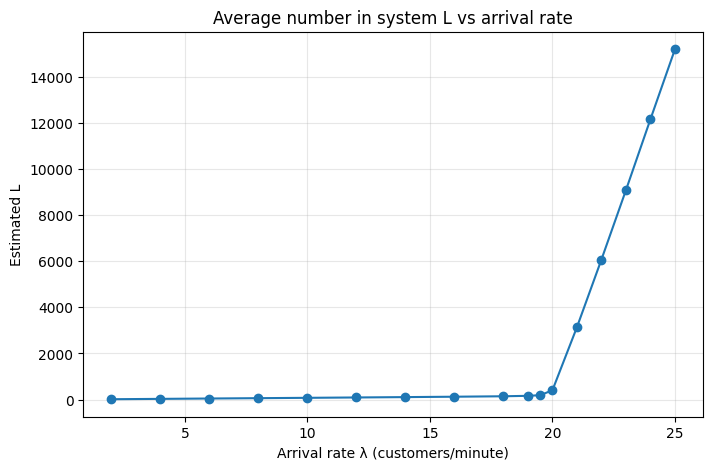

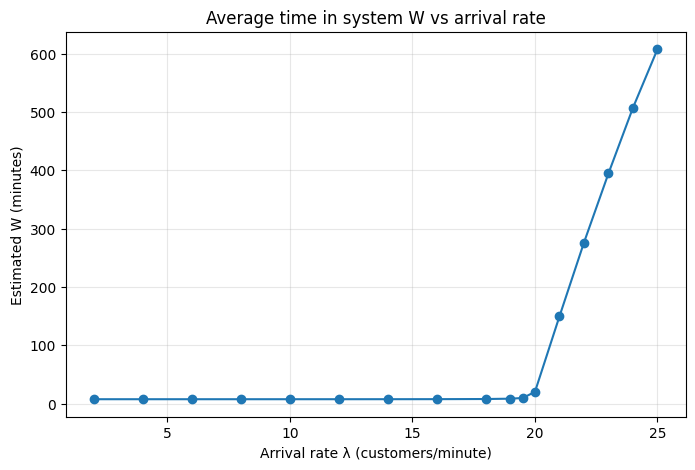

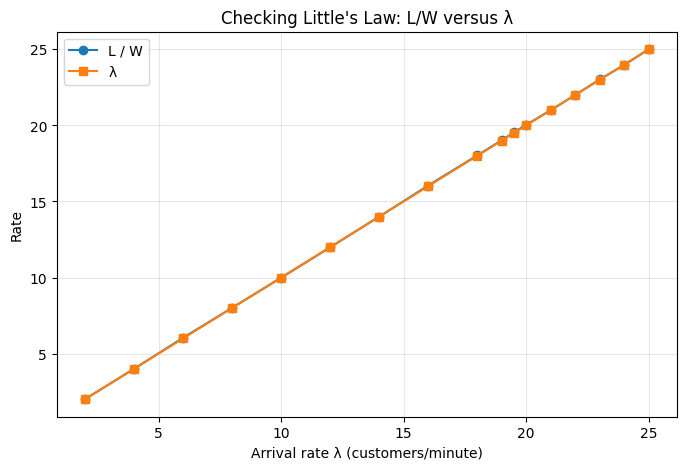

In [12]:
# Plot L and W as functions of lambda
plt.figure(figsize=(8, 5))
plt.plot(arrival_results["lambda"], arrival_results["L_mean"], marker="o")
plt.xlabel("Arrival rate λ (customers/minute)")
plt.ylabel("Estimated L")
plt.title("Average number in system L vs arrival rate")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(arrival_results["lambda"], arrival_results["W_mean"], marker="o")
plt.xlabel("Arrival rate λ (customers/minute)")
plt.ylabel("Estimated W (minutes)")
plt.title("Average time in system W vs arrival rate")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(arrival_results["lambda"], arrival_results["L_over_W"], marker="o", label="L / W")
plt.plot(arrival_results["lambda"], arrival_results["lambda"], marker="s", label="λ")
plt.xlabel("Arrival rate λ (customers/minute)")
plt.ylabel("Rate")
plt.title("Checking Little's Law: L/W versus λ")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Conclusion for Task 1

From the simulation results:

1. **Stable range of arrival rates**  
   The system behaves as stable for rates **below about 20 customers/minute**.  
   Around **$(\lambda = 20)$** the system starts to deteriorate sharply, and for **$(\lambda > 20)$** the average number in system grows dramatically.

2. **Reason for the stability threshold**  
   The bottleneck is the security stage, which has capacity about:
   $
   10 \times 2 = 20 \text{ customers/minute}
   $
   So the simulation agrees with the queueing-capacity intuition.

3. **Little's Law**  
   For the stable cases, the plot shows that:
   $
   \frac{L}{W} \approx \lambda
   $
   or equivalently:
   $
   L \approx \lambda \cdot W
   $
   which is exactly **Little's Law**.

4. **Behavior near instability**  
   As $(\lambda)$ approaches the capacity limit, both $(L)$ and $(W)$ increase rapidly.  
   Once the arrival rate exceeds capacity, the queue cannot be cleared in the long run, so the system becomes unstable.

## Part 2.4 Task 2 — Optimizing the number of security screening stations

Now we keep the **default arrival rate $(\lambda = 10)$** and vary the number of security stations $(n_3)$.

The project asks us to:

1. find the range of $(n_3)$ for which the system is stable
2. compare throughput $(S)$ to the arrival rate
3. find the best $(n_3)$ in $\{1,2,\dots,20\}$ that minimizes
   $
   \text{cost} = L - S + 10n_3
   $

### Stability intuition

Security capacity with $(n_3)$ stations is:
$
2 \cdot n_3
$
customers per minute.

With $(\lambda = 10)$, we expect stability only when:
$
10 < 2 \cdot n_3
\quad \Longrightarrow \quad
n_3 > 5
$

Since $(n_3)$ must be an integer, we expect the stable range to begin at:

$
n_3 = 6
$

In [13]:
security_rows = []

for n3 in range(1, 21):
    rep_df, rep_summary = run_replications(
        arrival_rate=10,
        n1=25,
        n3=n3,
        warmup=500,
        collect_time=2000,
        nrep=5,
        seed0=8000 + 100 * n3,
    )

    L_mean = rep_summary.loc[rep_summary["metric"] == "L", "mean"].iloc[0]
    W_mean = rep_summary.loc[rep_summary["metric"] == "W", "mean"].iloc[0]
    S_mean = rep_summary.loc[rep_summary["metric"] == "S", "mean"].iloc[0]

    # Theoretical stability test based on capacity:
    stable = (10 < 2 * n3)

    # If unstable, the long-run cost is effectively infinite because L blows up.
    cost = (L_mean - S_mean + 10 * n3) if stable else math.inf

    security_rows.append({
        "n3": n3,
        "stable": stable,
        "L_mean": L_mean,
        "W_mean": W_mean,
        "S_mean": S_mean,
        "cost": cost,
    })

security_results = pd.DataFrame(security_rows)
security_results

,n3,stable,L_mean,W_mean,S_mean,cost
0,1,False,12008.131014,1204.386595,2.0090,inf
1,2,False,9011.563577,897.405425,3.9753,inf
2,3,False,5898.150288,590.603215,6.0472,inf
3,4,False,3097.145567,308.837817,8.0272,inf
4,5,False,184.735737,18.399245,9.9997,inf
5,6,True,78.998333,7.899351,10.0007,128.997633
6,7,True,77.004577,7.695859,10.0079,136.996677
7,8,True,76.702368,7.637405,10.0423,146.660068
8,9,True,76.264442,7.618180,10.0133,156.251142
9,10,True,76.507302,7.612603,10.0519,166.455402


In [14]:
stable_security = security_results[security_results["stable"]].copy()
best_row = stable_security.loc[stable_security["cost"].idxmin()]
best_row

n3                 6
stable          True
L_mean     78.998333
W_mean      7.899351
S_mean       10.0007
cost      128.997633
Name: 5, dtype: object

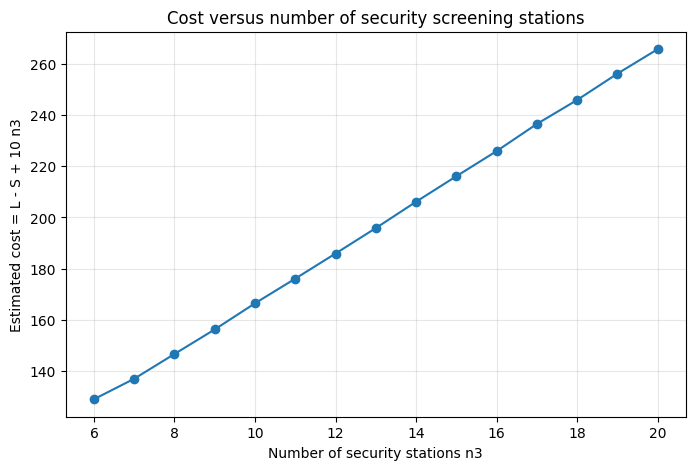

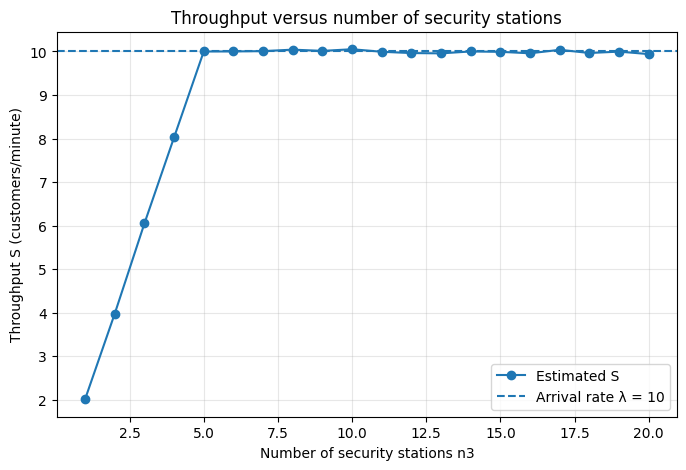

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(stable_security["n3"], stable_security["cost"], marker="o")
plt.xlabel("Number of security stations n3")
plt.ylabel("Estimated cost = L - S + 10 n3")
plt.title("Cost versus number of security screening stations")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(security_results["n3"], security_results["S_mean"], marker="o", label="Estimated S")
plt.axhline(10, linestyle="--", label="Arrival rate λ = 10")
plt.xlabel("Number of security stations n3")
plt.ylabel("Throughput S (customers/minute)")
plt.title("Throughput versus number of security stations")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### **Conclusion for the security-staffing optimization**

From the simulation and the capacity argument:

1. **Stable range of $(n_3)$**  
   The system is stable for:
   $
   n_3 \ge 6
   $
   and unstable for:
   $
   n_3 \le 5
   $

2. **How does $(S)$ compare to $(\lambda)$?**  
   For stable systems, throughput satisfies:
   $
   S \approx \lambda = 10
   $
   because in steady state the long-run output rate must match the long-run input rate.  
   For unstable systems, throughput cannot keep up with arrivals and instead saturates near the maximum service capacity of the bottleneck.

3. **Best number of screening stations**  
   The estimated cost is minimized at:
   $
   n_3 = 6
   $
   This makes intuitive sense:
   - $(n_3 = 6)$ is the **smallest stable staffing level**
   - increasing $(n_3)$ further slightly reduces congestion, but not by enough to compensate for the added staffing cost term $(10 \cdot n_3)$

So the best trade-off, under the project's cost function, is to open **6 security screening stations**.

## Final summary for Part 2

This notebook built a **discrete-event simulation** of the airport pre-boarding system using the lecture methodology:

- explicit system state
- explicit event types
- future event list
- event handlers
- time-average and customer-average statistics
- Monte Carlo replications with confidence intervals
- warm-up based steady-state analysis for long-run questions

### Main findings

- Under the default parameters, the one-day Monte Carlo simulation gives sensible estimates of $(L)$, $(W)$, and $(S)$ with confidence intervals.
- The system is stable for arrival rates approximately:
  $
  \lambda < 20
  $
- The simulation confirms **Little's Law**:
  $
  L \approx \lambda \cdot W
  $
- With default arrival rate $(\lambda = 10)$, the security line is stable when:
  $
  n_3 \ge 6
  $
- The cost-minimizing number of security screening stations in $\{1,2,\dots,20\}$ is:
  $
  n_3^* = 6
  $

This completes **Part 2** of the project.